<a href="https://colab.research.google.com/github/Arishkkkin/IZERGINA-DIPLOM/blob/main/%D0%94%D0%98%D0%9F%D0%9B%D0%9E%D0%9C_%D0%98%D0%97%D0%95%D0%A0%D0%93%D0%98%D0%9D%D0%90_%D0%9F%D0%98%D0%91_222_1%D0%A7%D0%90%D0%A1%D0%A2%D0%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**БЛОК 1: УСТАНОВКА БИБЛИОТЕК**

Он устанавливает все необходимые библиотеки. В Google Colab используется !pip для установки пакетов.

In [1]:
# TensorFlow - основная библиотека для глубокого обучения
!pip install tensorflow

# Keras - высокоуровневый API для нейронных сетей
!pip install keras --upgrade

# scikit-learn - для разделения данных и метрик качества
!pip install scikit-learn

# OpenCV - для обработки изображений (чтение, изменение размера)
!pip install opencv-python

# Matplotlib - для построения графиков и визуализации
!pip install matplotlib

# NumPy - для работы с массивами данных
!pip install numpy

# Pandas - для работы с табличными данными
!pip install pandas

# Pillow - для работы с изображениями
!pip install pillow

# Seaborn - для визуализации матрицы ошибок
!pip install seaborn

# Ultralytics YOLO - для детекции объектов
!pip install ultralytics

# OpenCV головная версия (без GUI)
!pip install opencv-python-headless

print("Все библиотеки успешно установлены!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.5 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.13.2
    Uninstalling keras-3.13.2:
      Successfully uninstalled keras-3.13.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.3 MB/s eta 0:00:00
Все библиотеки успешно установлены!



**БЛОК 1.1: ИМПОРТ БИБЛИОТЕК**

После установки импортируем все библиотеки для использования в коде

In [2]:
import os
import shutil
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from PIL import Image
from ipywidgets import interact, IntSlider

# TensorFlow и Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Ultralytics YOLO
from ultralytics import YOLO

# Настройки
warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

# Фиксация seed для воспроизводимости
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

print("Библиотеки импортированы")
print(f"TensorFlow: {tf.__version__}")
print(f"OpenCV: {cv2.__version__}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Библиотеки импортированы
TensorFlow: 2.20.0
OpenCV: 4.13.0


**БЛОК 2: ПОДКЛЮЧЕНИЕ GOOGLE ДИСКА**

Этот блок монтирует Google Диск к Colab, чтобы получить доступ к файлам.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = '/content/drive/MyDrive/ДИПЛОМ/bike_dataset'

# Проверка наличия датасета
if os.path.exists(DATASET_PATH):
    files = os.listdir(DATASET_PATH)
    print(f"Датасет найден. Количество файлов: {len(files)}")
else:
    print(f"Ошибка: датасет не найден по пути {DATASET_PATH}")

Mounted at /content/drive
Датасет найден. Количество файлов: 5185


**БЛОК 3: ЗАГРУЗКА МОДЕЛИ YOLO**

In [4]:
model_yolo = YOLO('yolov8n.pt')
print("Модель YOLO загружена")

Модель YOLO загружена


**БЛОК 4: ФУНКЦИИ ДЛЯ ДЕТЕКЦИИ ВЕЛОСИПЕДА**

In [5]:
def find_bike_advanced(image):
    """
    Комбинированный поиск велосипеда на изображении.

    Этапы:
    1. Детекция с помощью YOLO
    2. Вычитание зеленого фона (HSV)
    3. Контурный анализ
    4. Fallback: поиск по краям (Canny)

    Возвращает: (center_x, center_y, confidence)
    """
    h, w = image.shape[:2]

    # ---- Этап 1: YOLO ----
    results = model_yolo(image, verbose=False)
    best_box = None
    best_conf = 0.0

    for r in results:
        for box in r.boxes:
            if int(box.cls[0]) == 1:  # bicycle
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                conf = float(box.conf[0])
                if conf > best_conf:
                    best_conf = conf
                    best_box = (x1, y1, x2, y2)

    if best_box and best_conf > 0.4:
        x1, y1, x2, y2 = best_box
        return (x1 + x2) / 2, (y1 + y2) / 2, best_conf

    # ---- Этап 2: Вычитание зеленого фона ----
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    lower_green = np.array([35, 40, 40])
    upper_green = np.array([85, 255, 255])
    mask_green = cv2.inRange(hsv, lower_green, upper_green)
    mask_obj = cv2.bitwise_not(mask_green)

    kernel = np.ones((5, 5), np.uint8)
    mask_obj = cv2.morphologyEx(mask_obj, cv2.MORPH_CLOSE, kernel)
    mask_obj = cv2.morphologyEx(mask_obj, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(mask_obj, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        valid_contours = []
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < 500 or area > 0.8 * h * w:
                continue
            x, y, cw, ch = cv2.boundingRect(cnt)
            aspect = cw / ch if ch > 0 else 0
            if 0.4 < aspect < 2.5:
                valid_contours.append((area, x, y, cw, ch))

        if valid_contours:
            _, x, y, cw, ch = max(valid_contours, key=lambda t: t[0])
            return x + cw / 2, y + ch / 2, 0.5

    # ---- Этап 3: Поиск по краям (Canny) ----
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(largest)
        if 0.01 < area / (h * w) < 0.7:
            x, y, cw, ch = cv2.boundingRect(largest)
            return x + cw / 2, y + ch / 2, 0.3

    # ---- Этап 4: Fallback ----
    return w / 2, h / 2, 0.0


def get_section_from_coordinates(center_x, center_y, image_width, image_height):
    """
    Определяет номер секции (1-9) по координатам центра велосипеда.
    Изображение делится на сетку 3x3.
    """
    section_w = image_width / 3
    section_h = image_height / 3

    col = int(center_x // section_w)
    row = int(center_y // section_h)

    col = max(0, min(2, col))
    row = max(0, min(2, row))

    section = row * 3 + col + 1
    return section, section - 1  # возвращаем номер секции и индекс (0-8)

print("Функции детекции велосипеда загружены")

Функции детекции велосипеда загружены


**БЛОК 4.1: ЗАГРУЗКА И ОБРАБОТКА ДАННЫХ**

In [6]:
def load_images_advanced(folder_path, img_size=(224, 224)):
    """
    Загружает изображения, детектирует велосипеды,
    определяет секции и уровень уверенности.

    ВАЖНО: Сохраняется ВСЕ изображение (ресайз), а не обрезка велосипеда.
    Секция определяется по координатам центра велосипеда в исходном кадре.

    Возвращает:
    - images: массив нормализованных изображений (ВСЕ изображение)
    - labels: массив меток секций (0-8)
    - coordinates: список координат центров
    - confidences: список уровней уверенности
    - filenames: список имен файлов
    """
    images = []
    filenames = []
    labels = []
    coordinates = []
    confidences = []
    errors = []
    low_conf_count = 0

    image_extensions = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')
    all_files = os.listdir(folder_path)
    image_files = [f for f in all_files if f.endswith(image_extensions)]

    print(f"Найдено изображений: {len(image_files)}")

    for i, img_file in enumerate(image_files):
        img_path = os.path.join(folder_path, img_file)
        img = cv2.imread(img_path)

        if img is None:
            errors.append(img_file)
            continue

        # Детекция велосипеда
        bike_x, bike_y, conf = find_bike_advanced(img)
        coordinates.append((bike_x, bike_y))
        confidences.append(conf)

        if conf < 0.5:
            low_conf_count += 1

        # Определение секции (по координатам центра в исходном кадре)
        h, w = img.shape[:2]
        section, label = get_section_from_coordinates(bike_x, bike_y, w, h)
        labels.append(label)


        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, img_size)
        img_norm = img_resized.astype('float32') / 255.0
        images.append(img_norm)
        filenames.append(img_file)

        if (i + 1) % 500 == 0:
            print(f"   Обработано {i + 1}/{len(image_files)}")

    # Вывод статистики
    print(f"\nРЕЗУЛЬТАТЫ ДЕТЕКЦИИ:")
    print(f"   Загружено: {len(images)}")
    print(f"   Ошибок: {len(errors)}")
    print(f"   Низкая уверенность (<0.5): {low_conf_count}")

    unique, counts = np.unique(labels, return_counts=True)
    print(f"\nРАСПРЕДЕЛЕНИЕ ПО СЕКЦИЯМ:")
    for u, c in zip(unique, counts):
        print(f"   Секция {u + 1}: {c} изображений")

    return np.array(images), np.array(labels), coordinates, confidences, filenames

print("\n" + "="*60)
print("ЗАГРУЗКА ДАННЫХ")
print("="*60)

X, y, coords, confs, fnames = load_images_advanced(DATASET_PATH)

print("\nЗАГРУЗКА ЗАВЕРШЕНА!")
print(f"X.shape: {X.shape}")
print(f"y.shape: {y.shape}")


ЗАГРУЗКА ДАННЫХ
Найдено изображений: 5185
   Обработано 500/5185
   Обработано 1000/5185
   Обработано 1500/5185
   Обработано 2000/5185
   Обработано 2500/5185
   Обработано 3000/5185
   Обработано 3500/5185
   Обработано 4000/5185
   Обработано 4500/5185
   Обработано 5000/5185

РЕЗУЛЬТАТЫ ДЕТЕКЦИИ:
   Загружено: 5185
   Ошибок: 0
   Низкая уверенность (<0.5): 0

РАСПРЕДЕЛЕНИЕ ПО СЕКЦИЯМ:
   Секция 1: 496 изображений
   Секция 2: 511 изображений
   Секция 3: 507 изображений
   Секция 4: 481 изображений
   Секция 5: 629 изображений
   Секция 6: 547 изображений
   Секция 7: 598 изображений
   Секция 8: 785 изображений
   Секция 9: 631 изображений

ЗАГРУЗКА ЗАВЕРШЕНА!
X.shape: (5185, 224, 224, 3)
y.shape: (5185,)


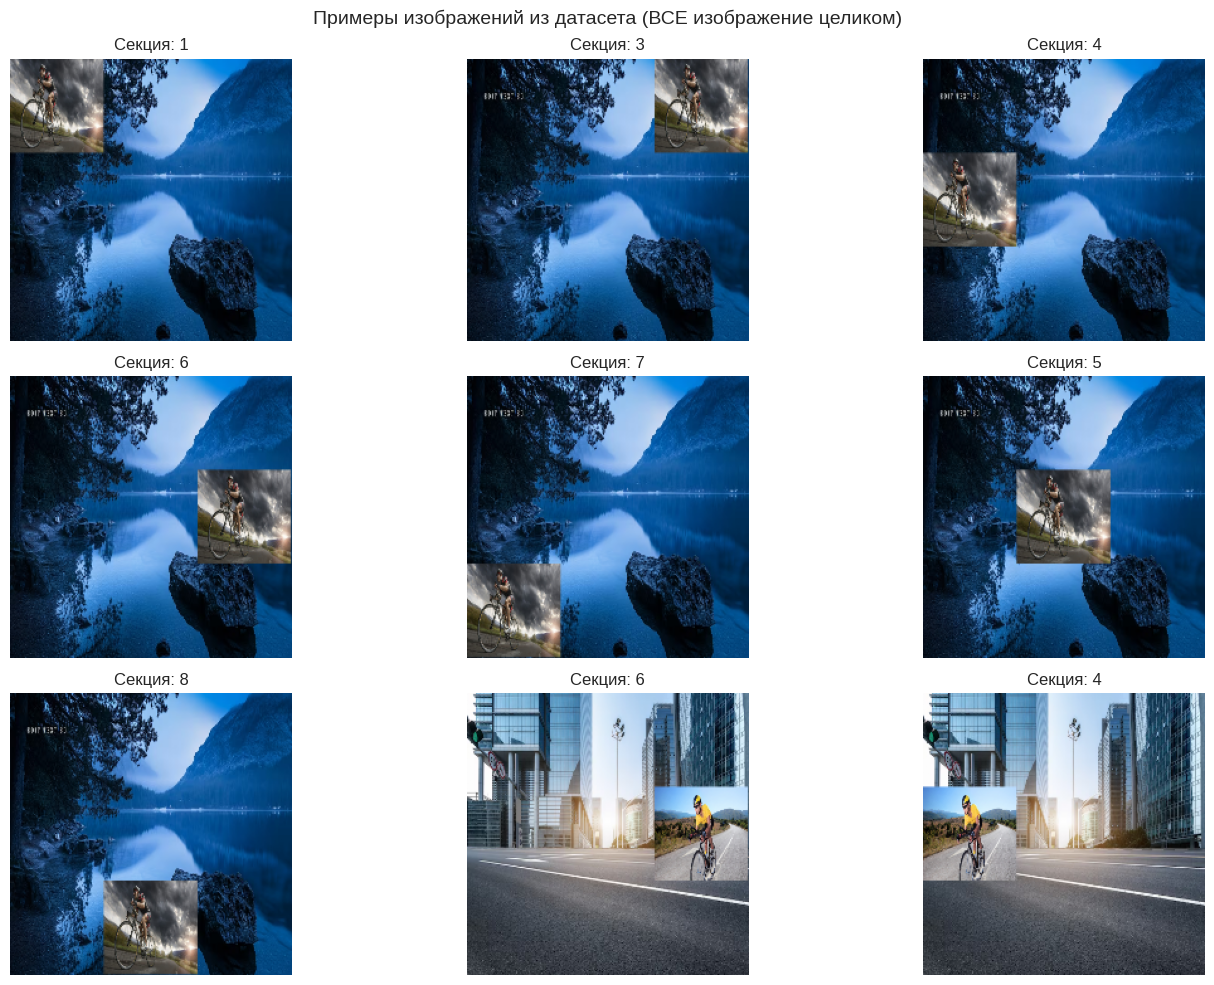

Форма изображения: (224, 224, 3)
Должно быть (224, 224, 3) - весь кадр, а не только велосипед


In [7]:
# ============================================
# ПРОВЕРКА ПРАВИЛЬНОСТИ ДАТАСЕТА
# ============================================

# Покажем несколько изображений с их секциями
plt.figure(figsize=(15, 10))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(X[i])
    plt.title(f'Секция: {y[i] + 1}')
    plt.axis('off')

plt.suptitle('Примеры изображений из датасета (ВСЕ изображение целиком)', fontsize=14)
plt.tight_layout()
plt.show()

# Проверка, что изображения содержат контекст
print(f"Форма изображения: {X[0].shape}")
print(f"Должно быть (224, 224, 3) - весь кадр, а не только велосипед")

In [ ]:
# ============================================
# СОХРАНЕНИЕ ДАТАСЕТА (ВСЕ ФОРМАТЫ)
# ============================================

import numpy as np
import os
import json
import cv2

save_dir = '/content/drive/MyDrive/ДИПЛОМ/bike_dataset'
os.makedirs(save_dir, exist_ok=True)

print("\n" + "="*60)
print("СОХРАНЕНИЕ ДАТАСЕТА")
print("="*60)

# 1. Сохраняем numpy массивы
np.save(os.path.join(save_dir, 'X.npy'), X)
np.save(os.path.join(save_dir, 'y.npy'), y)
np.save(os.path.join(save_dir, 'coords.npy'), np.array(coords))
np.save(os.path.join(save_dir, 'confs.npy'), np.array(confs))

# 2. Сохраняем размеры исходных изображений
image_sizes = []
for fname in fnames:
    img_path = os.path.join(DATASET_PATH, fname)
    img = cv2.imread(img_path)
    if img is not None:
        h, w = img.shape[:2]
        image_sizes.append((w, h))
    else:
        image_sizes.append((0, 0))
np.save(os.path.join(save_dir, 'image_sizes.npy'), np.array(image_sizes))

# 3. Сохраняем имена файлов
with open(os.path.join(save_dir, 'fnames.txt'), 'w') as f:
    for name in fnames:
        f.write(f"{name}\n")

# 4. Сохраняем TXT аннотации (для удобного просмотра)
with open(os.path.join(save_dir, 'annotations.txt'), 'w') as f:
    f.write("# filename | section | center_x | center_y | img_width | img_height | confidence\n")
    f.write("#" + "="*80 + "\n")
    for i, fname in enumerate(fnames):
        section = y[i] + 1
        cx, cy = coords[i]
        w, h = image_sizes[i]
        conf = confs[i]
        f.write(f"{fname} | {section} | {cx:.1f} | {cy:.1f} | {w} | {h} | {conf:.3f}\n")

# 5. Сохраняем метаинформацию JSON
info = {
    'num_samples': int(X.shape[0]),
    'image_shape': (224, 224, 3),
    'num_classes': int(len(np.unique(y))),
    'classes': [int(c) for c in np.unique(y)],
    'has_coords': True,
    'has_confs': True,
    'has_image_sizes': True,
    'description': 'Полные изображения (ресайз 224x224) с координатами центра велосипеда'
}
with open(os.path.join(save_dir, 'dataset_info.json'), 'w') as f:
    json.dump(info, f, indent=2)

# 6. Вывод статистики
print("\nСохраненные файлы:")
print(f"   X.npy              - {X.shape} - изображения (224x224x3)")
print(f"   y.npy              - {y.shape} - метки секций (0-8)")
print(f"   coords.npy         - {len(coords)} - координаты центров")
print(f"   confs.npy          - {len(confs)} - уверенность детекции")
print(f"   image_sizes.npy    - {len(image_sizes)} - размеры исходных фото")
print(f"   fnames.txt         - {len(fnames)} - имена файлов")
print(f"   annotations.txt    - {len(fnames)} - аннотации (читаемый формат)")
print(f"   dataset_info.json  - метаинформация")

print(f"\nДатасет сохранен в: {save_dir}")
print("="*60)
print("СОХРАНЕНИЕ ЗАВЕРШЕНО")
print("="*60)

**БЛОК 4.2: ФИЛЬТРАЦИЯ И ПЕРЕМЕЩЕНИЕ ФОТО С НИЗКОЙ УВЕРЕННОСТЬЮ**

In [8]:
CONFIDENCE_THRESHOLD = 0.5
CLEAN_FOLDER = "clean"

def move_low_confidence_images(dataset_path, confidences, filenames, threshold=0.5, output_folder="clean"):
    """
    Перемещает изображения с низкой уверенностью в отдельную папку.
    Возвращает список перемещенных файлов и индексы для сохранения.
    """
    os.makedirs(output_folder, exist_ok=True)

    moved_files = []
    keep_indices = []

    for i, (conf, fname) in enumerate(zip(confidences, filenames)):
        if conf < threshold:
            src_path = os.path.join(dataset_path, fname)
            dst_path = os.path.join(output_folder, fname)

            # Обработка дубликатов
            counter = 1
            while os.path.exists(dst_path):
                name, ext = os.path.splitext(fname)
                dst_path = os.path.join(output_folder, f"{name}_{counter}{ext}")
                counter += 1

            if os.path.exists(src_path):
                shutil.move(src_path, dst_path)
                moved_files.append((fname, conf))
        else:
            keep_indices.append(i)

    return moved_files, keep_indices


def filter_arrays_by_indices(X, y, coords, confs, fnames, indices):
    """Фильтрует массивы по заданным индексам."""
    if len(indices) > 0:
        X_filtered = X[indices]
        y_filtered = y[indices]
        coords_filtered = [coords[i] for i in indices]
        confs_filtered = [confs[i] for i in indices]
        fnames_filtered = [fnames[i] for i in indices]
    else:
        X_filtered = np.array([])
        y_filtered = np.array([])
        coords_filtered = []
        confs_filtered = []
        fnames_filtered = []

    return X_filtered, y_filtered, coords_filtered, confs_filtered, fnames_filtered


print("\n" + "="*60)
print("ПЕРЕМЕЩЕНИЕ ФОТО С НИЗКОЙ УВЕРЕННОСТЬЮ")
print("="*60)

moved_files, keep_indices = move_low_confidence_images(
    DATASET_PATH, confs, fnames, CONFIDENCE_THRESHOLD, CLEAN_FOLDER
)

print(f"Перемещено в папку '{CLEAN_FOLDER}': {len(moved_files)} фото")

# Фильтрация массивов данных
X_final, y_final, coords_final, confs_final, fnames_final = filter_arrays_by_indices(
    X, y, coords, confs, fnames, keep_indices
)

print(f"Финальный датасет: {len(X_final)} изображений (высокая уверенность)")



ПЕРЕМЕЩЕНИЕ ФОТО С НИЗКОЙ УВЕРЕННОСТЬЮ
Перемещено в папку 'clean': 0 фото
Финальный датасет: 5185 изображений (высокая уверенность)


**БЛОК 5.1: ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ДЕТЕКЦИИ**


ВИЗУАЛИЗАЦИЯ ДАННЫХ


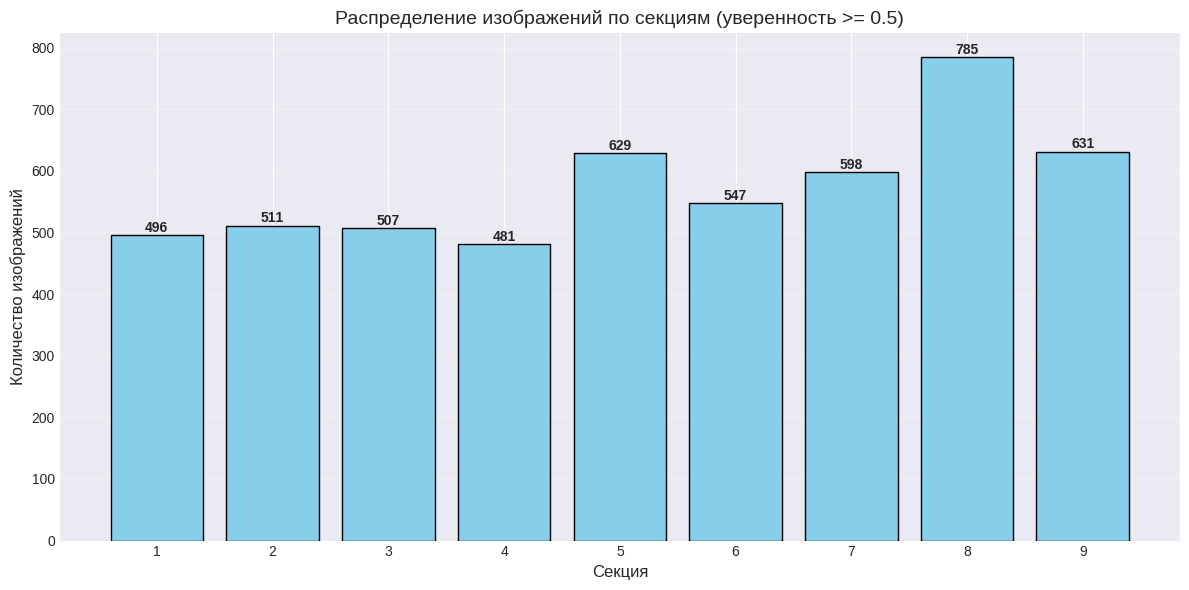


СТАТИСТИКА ДАТАСЕТА:
   Всего изображений: 5185
   Количество секций: 9
   Минимум в секции: 481
   Максимум в секции: 785
   Среднее в секции: 576.1
   Средняя уверенность: 0.800

ПРИМЕРЫ ИЗОБРАЖЕНИЙ ИЗ ДАТАСЕТА:


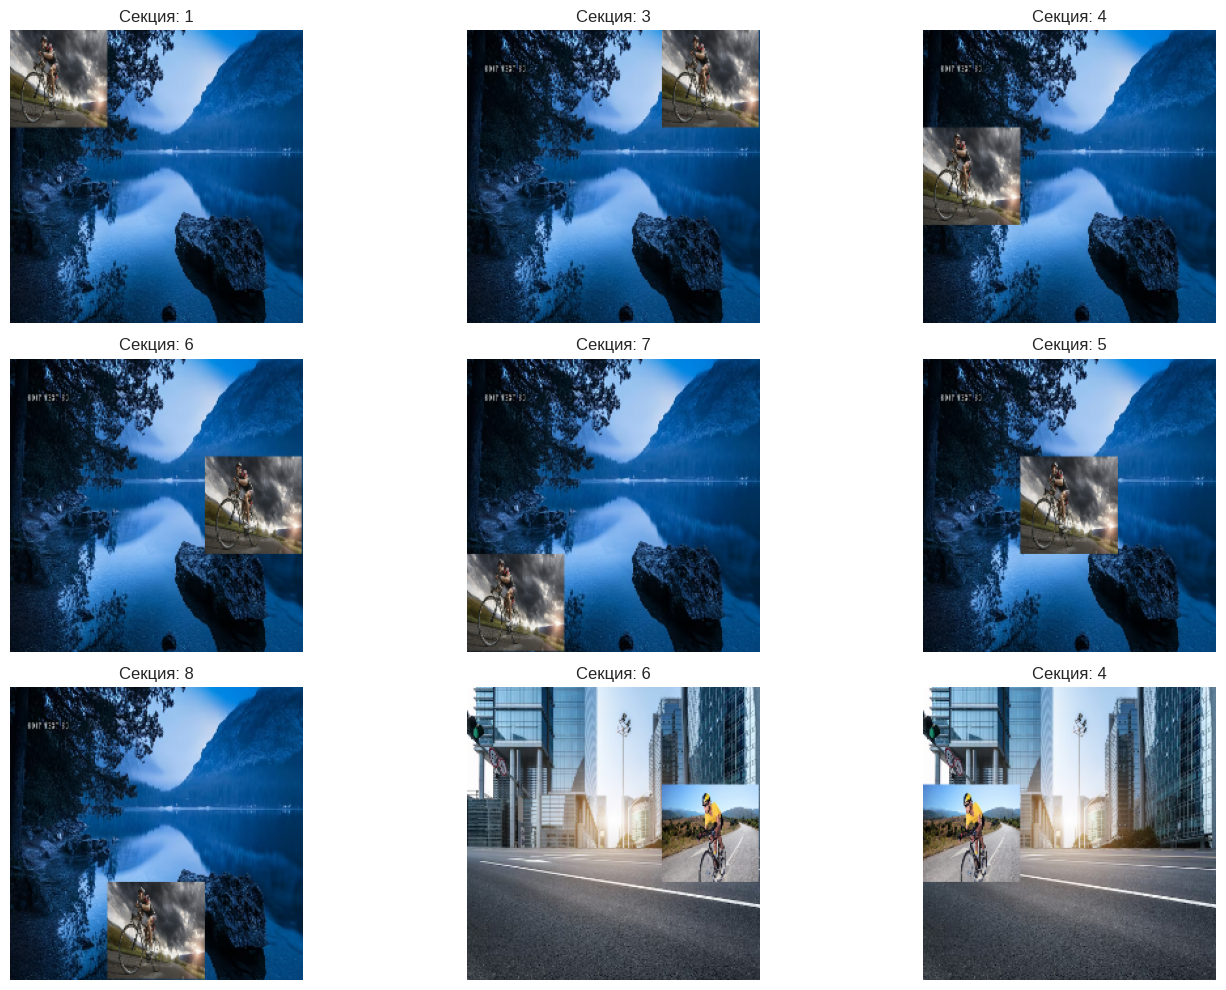

In [10]:
# ============================================
# ВИЗУАЛИЗАЦИЯ ДАННЫХ (ИСПРАВЛЕННАЯ)
# ============================================

CONFIDENCE_THRESHOLD = 0.5

# Проверяем, есть ли данные
if len(X_final) > 0:
    print("\n" + "="*60)
    print("ВИЗУАЛИЗАЦИЯ ДАННЫХ")
    print("="*60)

    # Распределение по секциям
    unique, counts = np.unique(y_final + 1, return_counts=True)

    plt.figure(figsize=(12, 6))
    bars = plt.bar(unique, counts, color='skyblue', edgecolor='black')
    plt.xlabel('Секция', fontsize=12)
    plt.ylabel('Количество изображений', fontsize=12)
    plt.title(f'Распределение изображений по секциям (уверенность >= {CONFIDENCE_THRESHOLD})', fontsize=14)
    plt.xticks(range(1, 10))
    plt.grid(True, alpha=0.3, axis='y')

    for bar, count in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Статистика
    print("\nСТАТИСТИКА ДАТАСЕТА:")
    print(f"   Всего изображений: {len(X_final)}")
    print(f"   Количество секций: {len(unique)}")
    print(f"   Минимум в секции: {min(counts)}")
    print(f"   Максимум в секции: {max(counts)}")
    print(f"   Среднее в секции: {np.mean(counts):.1f}")
    print(f"   Средняя уверенность: {np.mean(confs_final):.3f}")

    # Покажем несколько изображений
    print("\nПРИМЕРЫ ИЗОБРАЖЕНИЙ ИЗ ДАТАСЕТА:")
    plt.figure(figsize=(15, 10))
    for i in range(min(9, len(X_final))):
        plt.subplot(3, 3, i+1)
        plt.imshow(X_final[i])
        plt.title(f'Секция: {y_final[i] + 1}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

else:
    print("\nНет данных с высокой уверенностью для визуализации")
    print(f"Всего фото после фильтрации: {len(X_final)}")